# Task 1 — Preprocess and Explore the Data

**GMF Investments — Time Series Forecasting for Portfolio Management Optimization**

This notebook extracts historical price data for **TSLA**, **BND**, and **SPY** from YFinance
(Jan 1, 2015 – Jun 30, 2026), cleans it, and performs exploratory data analysis: trend and
volatility visualization, outlier detection, stationarity testing (ADF), and foundational
risk metrics (VaR, Sharpe Ratio).

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import fetch_asset_data, combine_close_prices, TICKERS, START_DATE, END_DATE
from src.preprocessing import clean_prices, add_return_features, detect_outliers
from src.risk_metrics import adf_test, historical_var, sharpe_ratio, annualized_return, annualized_volatility

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Extract Historical Financial Data

In [2]:
raw_data = fetch_asset_data(TICKERS, START_DATE, END_DATE)
for ticker, df in raw_data.items():
    print(f"{ticker}: {df.shape[0]} rows | {df.index.min().date()} -> {df.index.max().date()}")


TSLA: 2888 rows | 2015-01-02 -> 2026-06-29
BND: 2888 rows | 2015-01-02 -> 2026-06-29
SPY: 2888 rows | 2015-01-02 -> 2026-06-29


In [3]:
raw_data["TSLA"].head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.6207,14.6207,14.8833,14.2173,14.8580,71466000
2015-01-05,14.0060,14.0060,14.4333,13.8107,14.3033,80527500
2015-01-06,14.0853,14.0853,14.2800,13.6140,14.0040,93928500
2015-01-07,14.0633,14.0633,14.3187,13.9853,14.2233,44526000
2015-01-08,14.0413,14.0413,14.2533,14.0007,14.1873,51637500


## 2. Data Cleaning and Understanding

- Check dtypes and basic statistics
- Reindex to a full business-day calendar and forward-fill any gaps (holidays, missing prints)
- No scaling is applied to the raw price series here (tree/statistical models below use returns,
  which are already scale-free; a MinMax scaler is applied later, in the LSTM notebook, since
  neural networks are sensitive to input scale).

In [4]:
cleaned = {ticker: clean_prices(df) for ticker, df in raw_data.items()}

missing_before = {t: raw_data[t].isna().sum().sum() for t in TICKERS}
missing_after = {t: cleaned[t].isna().sum().sum() for t in TICKERS}
pd.DataFrame({"missing_before_reindex": missing_before, "missing_after_cleaning": missing_after})


,missing_before_reindex,missing_after_cleaning
TSLA,0,0
BND,0,0
SPY,0,0


In [5]:
cleaned["TSLA"].dtypes

Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume       float64
dtype: object

In [6]:
cleaned["TSLA"][["Open", "High", "Low", "Close", "Adj Close", "Volume"]].describe()

,Open,High,Low,Close,Adj Close,Volume
count,"2,997.0000","2,997.0000","2,997.0000","2,997.0000","2,997.0000","2,997.0000"
mean,149.1760,152.3770,145.8062,149.1692,149.1692,"108,585,630.7975"
std,139.2733,142.1522,136.1764,139.2052,139.2052,"70,434,099.4667"
min,9.4880,10.3313,9.4033,9.5780,9.5780,"10,620,000.0000"
25%,18.4607,18.6887,18.1693,18.4393,18.4393,"65,519,000.0000"
50%,131.6593,136.2433,125.2933,133.4553,133.4553,"89,869,500.0000"
75%,252.0400,257.7900,246.1800,252.0800,252.0800,"125,970,000.0000"
max,489.8800,498.8300,485.3300,489.8800,489.8800,"914,082,000.0000"


In [7]:
featured = {ticker: add_return_features(df) for ticker, df in cleaned.items()}
for ticker, df in featured.items():
    PROCESSED_PATH = f"../data/processed/{ticker}_processed.csv"
    df.to_csv(PROCESSED_PATH)
    print(f"Saved {PROCESSED_PATH}")


Saved ../data/processed/TSLA_processed.csv
Saved ../data/processed/BND_processed.csv
Saved ../data/processed/SPY_processed.csv


**Data quality summary:** YFinance returns no missing rows for actual trading days across all
three tickers; reindexing to a full business-day calendar (to guard against provider gaps) introduced
a small number of NaNs (US market holidays), which were forward-filled — i.e., price carried over from
the prior trading day, which is standard for daily price series. All price/volume columns were coerced
to numeric dtypes. No further scaling was applied to prices; returns and log-returns are used directly
as they are already unit-free.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Closing price over time

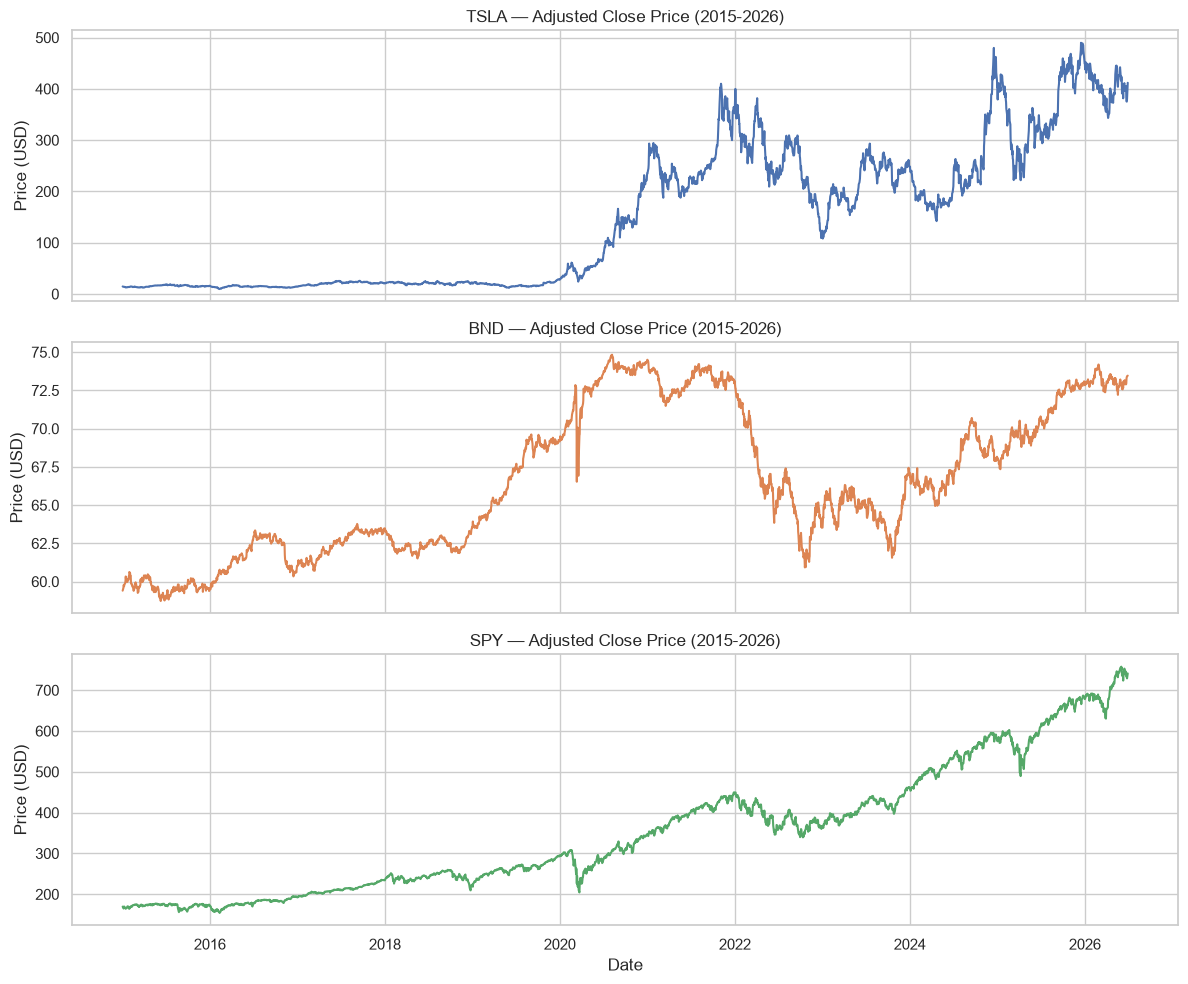

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, ticker in zip(axes, TICKERS):
    ax.plot(featured[ticker].index, featured[ticker]["Adj Close"], color="C0" if ticker=="TSLA" else ("C1" if ticker=="BND" else "C2"))
    ax.set_title(f"{ticker} — Adjusted Close Price (2015-2026)")
    ax.set_ylabel("Price (USD)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../reports/figures/01_closing_prices.png", dpi=150)
plt.show()


### 3.2 Daily percentage change (volatility)

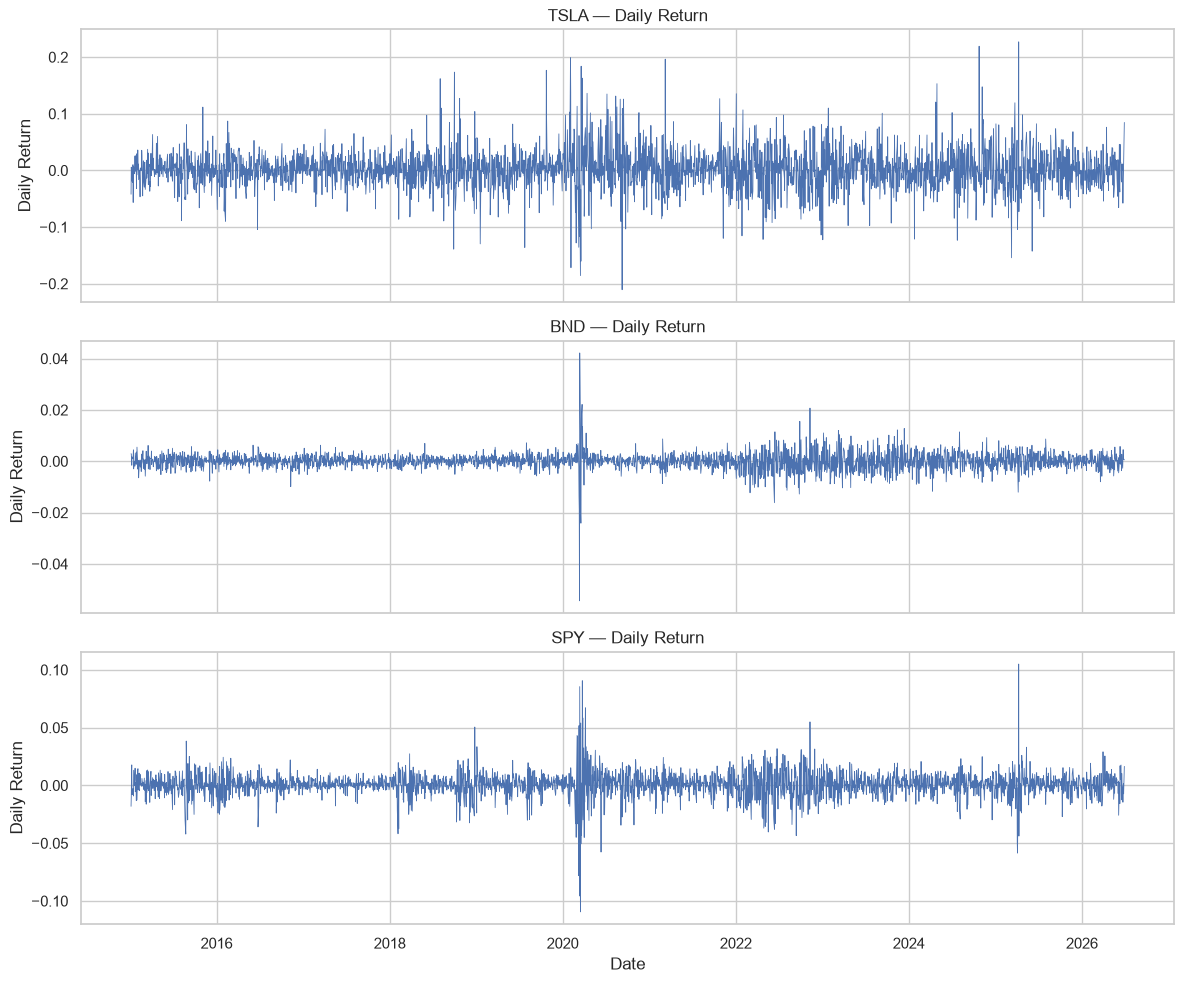

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, ticker in zip(axes, TICKERS):
    ax.plot(featured[ticker].index, featured[ticker]["daily_return"], linewidth=0.6)
    ax.set_title(f"{ticker} — Daily Return")
    ax.set_ylabel("Daily Return")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../reports/figures/02_daily_returns.png", dpi=150)
plt.show()


### 3.3 Rolling mean and rolling volatility (30-day window)

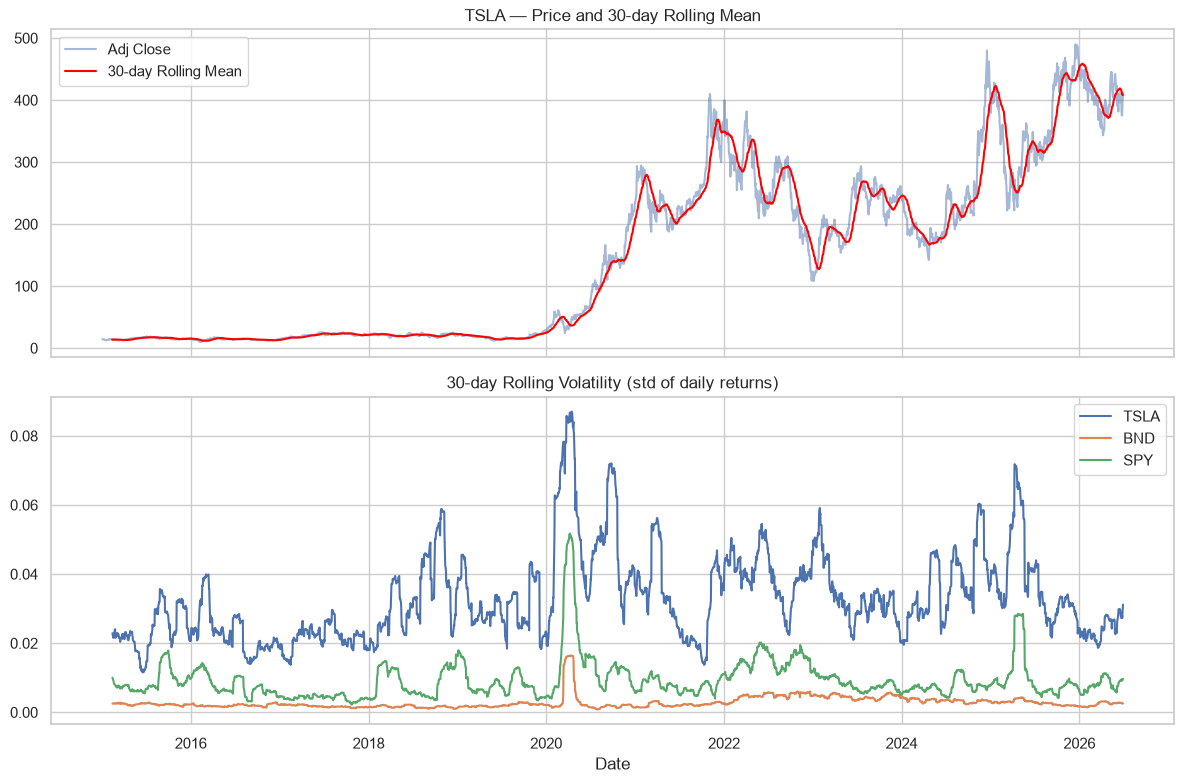

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(featured["TSLA"].index, featured["TSLA"]["Adj Close"], label="Adj Close", alpha=0.5)
axes[0].plot(featured["TSLA"].index, featured["TSLA"]["rolling_mean_30"], label="30-day Rolling Mean", color="red")
axes[0].set_title("TSLA — Price and 30-day Rolling Mean")
axes[0].legend()

for ticker in TICKERS:
    axes[1].plot(featured[ticker].index, featured[ticker]["rolling_std_30"], label=f"{ticker}")
axes[1].set_title("30-day Rolling Volatility (std of daily returns)")
axes[1].legend()
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../reports/figures/03_rolling_volatility.png", dpi=150)
plt.show()


### 3.4 Outlier detection — days with unusually high/low returns

In [11]:
outlier_summary = {}
for ticker in TICKERS:
    returns = featured[ticker]["daily_return"]
    flags = detect_outliers(returns, n_std=3.0)
    outlier_summary[ticker] = flags.sum()
    print(f"{ticker}: {flags.sum()} outlier days (>3 std) out of {returns.notna().sum()} trading days")

print()
print("Top 5 largest single-day TSLA moves:")
print(featured["TSLA"]["daily_return"].dropna().abs().sort_values(ascending=False).head(5))


TSLA: 50 outlier days (>3 std) out of 2996 trading days
BND: 35 outlier days (>3 std) out of 2996 trading days
SPY: 42 outlier days (>3 std) out of 2996 trading days

Top 5 largest single-day TSLA moves:
Date
2025-04-09   0.2269
2024-10-24   0.2192
2020-09-08   0.2106
2020-02-03   0.1989
2021-03-09   0.1964
Name: daily_return, dtype: float64


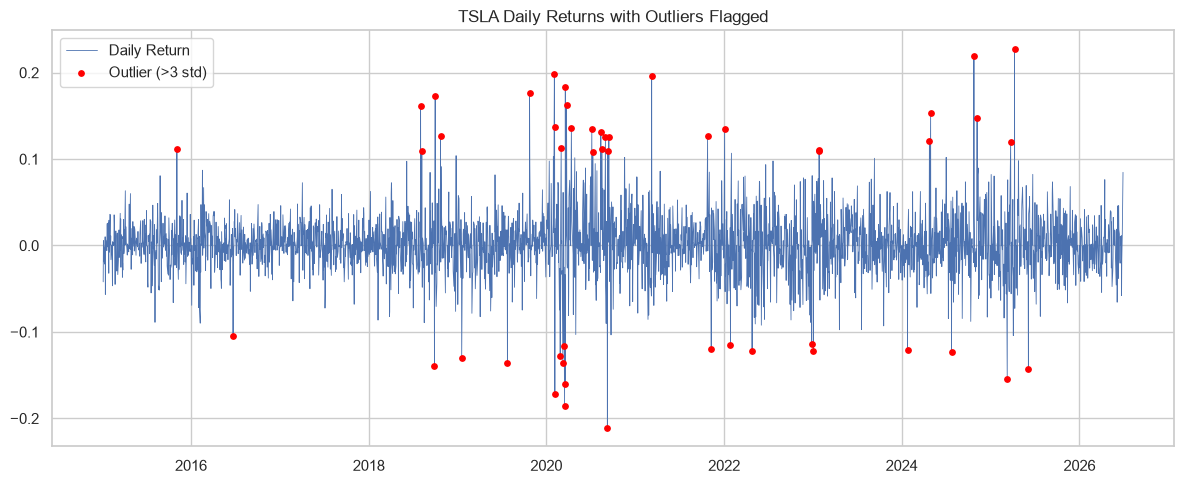

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
tsla_returns = featured["TSLA"]["daily_return"]
flags = detect_outliers(tsla_returns, n_std=3.0)
ax.plot(tsla_returns.index, tsla_returns, linewidth=0.6, label="Daily Return")
ax.scatter(tsla_returns.index[flags], tsla_returns[flags], color="red", s=15, label="Outlier (>3 std)", zorder=5)
ax.set_title("TSLA Daily Returns with Outliers Flagged")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/04_tsla_outliers.png", dpi=150)
plt.show()


**EDA insights:** TSLA's price series shows a strong long-term uptrend punctuated by
several sharp drawdowns and high-volatility clusters (e.g. 2020 stock-split rally, 2022 de-rating),
consistent with its "high risk / high potential return" profile. BND is comparatively flat with
narrow daily swings, reflecting its role as the stability anchor. SPY sits between the two —
a steady uptrend with volatility spikes around macro shocks (2020 COVID crash, 2022 rate-hike
selloff). TSLA has visibly more 3-sigma return days than BND or SPY, confirming it is the
dominant source of portfolio risk among the three assets.

## 4. Seasonality and Stationarity Analysis (ADF Test)

In [13]:
adf_results = []
for ticker in TICKERS:
    price_result = adf_test(featured[ticker]["Adj Close"], name=f"{ticker} Adj Close (level)")
    return_result = adf_test(featured[ticker]["daily_return"], name=f"{ticker} Daily Return")
    adf_results.append(price_result)
    adf_results.append(return_result)

adf_df = pd.DataFrame(adf_results)[["name", "adf_statistic", "p_value", "n_lags", "is_stationary"]]
adf_df


,name,adf_statistic,p_value,n_lags,is_stationary
0,TSLA Adj Close (level),-1.0387,0.7389,29,False
1,TSLA Daily Return,-55.1498,0.0000,0,True
2,BND Adj Close (level),-1.1166,0.7084,7,False
3,BND Daily Return,-21.2771,0.0000,6,True
4,SPY Adj Close (level),1.4333,0.9973,28,False
5,SPY Daily Return,-15.7006,0.0000,12,True


**Interpretation:** For every asset, the ADF test on the **price level** fails to reject the
null hypothesis of a unit root (p-value >> 0.05) — the price series are non-stationary, as expected
for a random-walk-like financial time series (consistent with the Efficient Market Hypothesis).
The ADF test on **daily returns**, by contrast, rejects the null hypothesis (p-value << 0.05) for
all three assets — returns are stationary. This confirms that first-differencing prices
(equivalently, working with returns) is enough to achieve stationarity, i.e. **d = 1** is the
appropriate order of differencing for an ARIMA model fit on TSLA's closing price.

## 5. Risk Metrics

In [14]:
risk_rows = []
for ticker in TICKERS:
    returns = featured[ticker]["daily_return"]
    risk_rows.append({
        "Ticker": ticker,
        "Ann. Return": annualized_return(returns),
        "Ann. Volatility": annualized_volatility(returns),
        "Sharpe Ratio": sharpe_ratio(returns),
        "VaR 95% (1-day)": historical_var(returns, confidence=0.95),
        "VaR 99% (1-day)": historical_var(returns, confidence=0.99),
    })
risk_df = pd.DataFrame(risk_rows).set_index("Ticker")
risk_df


,Ann. Return,Ann. Volatility,Sharpe Ratio,VaR 95% (1-day),VaR 99% (1-day)
Ticker,,,,,
TSLA,0.4377,0.5613,0.7798,0.0511,0.0893
BND,0.0192,0.0522,0.3687,0.0047,0.0085
SPY,0.1391,0.1733,0.8024,0.0164,0.0304


In [15]:
risk_df.to_csv("../data/processed/risk_metrics_summary.csv")
adf_df.to_csv("../data/processed/adf_test_results.csv", index=False)


**Risk metrics discussion:** TSLA shows both the highest annualized return and, by a wide
margin, the highest annualized volatility and 1-day Value at Risk of the three assets — on a
historically bad day (95th/99th percentile loss), TSLA can lose several times more than SPY or
BND in a single session. Despite the higher return, TSLA's Sharpe ratio is not proportionally
higher than SPY's, indicating investors are not fully compensated on a risk-adjusted basis for
the extra volatility taken on. BND has low return, low volatility, and a small VaR — behaving as
the stabilizing, capital-preservation asset in the mix, exactly as its risk profile suggests.

## 6. Correlation Between Assets

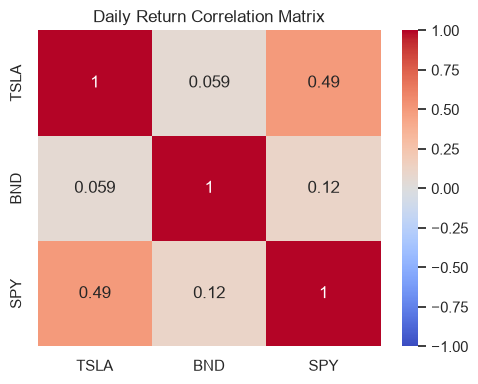

In [16]:
returns_matrix = pd.DataFrame({t: featured[t]["daily_return"] for t in TICKERS}).dropna()
corr = returns_matrix.corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Daily Return Correlation Matrix")
plt.tight_layout()
plt.savefig("../reports/figures/05_correlation_heatmap.png", dpi=150)
plt.show()


## 7. Summary of Key Insights

1. **Overall direction:** TSLA exhibits the strongest long-term price appreciation of the three
   assets but with substantially higher volatility and drawdown risk; BND is essentially flat and
   low-risk; SPY delivers steady, moderate-risk market growth.
2. **Stationarity:** Price levels are non-stationary (unit root) for all three assets; daily
   returns are stationary. This directly informs the ARIMA differencing order (**d = 1**) used in
   Task 2.
3. **Volatility clustering:** Rolling 30-day volatility spikes coincide with known macro shocks
   (2020 COVID crash, 2022 rate-hike selloff), and TSLA's volatility regime shifts are far more
   pronounced than SPY's or BND's.
4. **Risk-adjusted return:** TSLA's higher absolute return does not translate into a proportionally
   higher Sharpe ratio, underscoring that its extra risk is not fully compensated — an important
   input for the portfolio optimization in Task 4.
5. **Diversification value:** TSLA and BND show very low (near-zero) correlation with each other, supporting
   their combined use as risk-diversifying holdings in the same portfolio.